### Импорт библиотек

In [ ]:
!pip install scipy==1.11.1 scikit-learn wordcloud seaborn spacy typing_extensions==4.8.0

In [ ]:
!pip install pymorphy3

In [ ]:
!pip install gensim adjustText

In [ ]:
from time import time
import nltk
from nltk.corpus import stopwords
from nltk.corpus import wordnet as wn
from nltk.tokenize import word_tokenize, sent_tokenize
from nltk.stem import WordNetLemmatizer, PorterStemmer
from nltk.probability import FreqDist
from nltk import pos_tag
from nltk.collocations import BigramAssocMeasures, BigramCollocationFinder

nltk.download('punkt')
nltk.download('stopwords')
nltk.download('averaged_perceptron_tagger')
nltk.download('averaged_perceptron_tagger_eng')
nltk.download('averaged_perceptron_tagger_ru')
nltk.download('punkt_tab')
nltk.download('wordnet')
nltk.download('omw-1.4')

import spacy
from sklearn.manifold import TSNE
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, davies_bouldin_score
from sklearn.metrics.pairwise import cosine_similarity
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.gridspec import GridSpec
from wordcloud import WordCloud

import string
import pandas as pd
import numpy as np
import regex as re
import pymorphy3 as pm3
from charset_normalizer import detect

from adjustText import adjust_text
from collections import defaultdict

from time import time
from collections import defaultdict, Counter

import logging
import gensim
from gensim.models import FastText
from gensim.models.phrases import Phrases, Phraser
from gensim.models import KeyedVectors
import multiprocessing
logging.basicConfig(format="%(levelname)s - %(asctime)s: %(message)s", datefmt= '%H:%M:%S', level=logging.INFO)

In [ ]:
morph = pm3.MorphAnalyzer()
lemmatizer = WordNetLemmatizer()
stemmer = PorterStemmer()

In [ ]:
!python -m spacy download ru_core_news_sm

In [ ]:
ru_stopwords = set(stopwords.words('russian'))
# Расширенный набор "типографских" символов, которых нет в string.punctuation
EXTRA_PUNCT = '–—«»„""\u2026\u00ab\u00bb'

In [ ]:
ru_stopwords.add("это") # Добавляем в список слова, которых нет в основном множестве

## **Анализ данных**

### Чтение текста

In [ ]:
file_path  = '' # путь до текста в txt

In [ ]:
with open(file_path, 'rb') as f:
    raw_data = f.read()
encoding = detect(raw_data)['encoding']
print(f"Определенная кодировка: {encoding}")

Определенная кодировка: utf-8


In [ ]:
# Читаем строки
with open(file_path, 'r', encoding=encoding) as f:
    lines = [line.strip() for line in f if line.strip()]

df = pd.DataFrame(lines, columns=["input"])

### Предобработка

Вызов функции предобработки и создание датафрейма

In [ ]:
def nltk_pos_tag(word):
    # Получает POS для одного слова и преобразует NLTK-тег в формат для WordNetLemmatizer
    tag = nltk.pos_tag([word])[0][1]
    if tag.startswith('J'):
        return 'a'
    elif tag.startswith('V'):
        return 'v'
    elif tag.startswith('N'):
        return 'n'
    elif tag.startswith('R'):
        return 'r'
    else:
        return 'n'

In [ ]:
def preprocessing(line, remove_punctuation=True, remove_stopwords=True, normalisation=True):
    line = line.lower()

    # Заменяем переносы строк и табы на пробел
    line = re.sub(r'[\n\t]', ' ', line)

    # Удаляем типографские тире и кавычки отдельно (они не в string.punctuation)
    line = re.sub(r'[' + re.escape(EXTRA_PUNCT) + r']', ' ', line)

    # Оставляем только кириллицу, цифры, ASCII-пунктуацию и пробелы
    line = re.sub(r'[^а-яё0-9\s' + re.escape(string.punctuation) + r']', '', line)

    if remove_punctuation:
        line = re.sub(r'[' + re.escape(string.punctuation) + r']', ' ', line)

    # Токенизация + убираем пустые строки и одиночные символы
    words = [w for w in line.split() if len(w) > 1]

    if remove_stopwords:
        words = [w for w in words if w not in ru_stopwords]

    if normalisation:
        lemmas = [morph.parse(w)[0].normal_form for w in words]
    else:
        lemmas = words

    return ' '.join(lemmas)

Тест нормализации на одной строке

In [ ]:
test_line = "Да, мы не верим в бога, – чуть улыбнувшись испугу интуриста, ответил Берлиоз. – Но об этом можно говорить совершенно свободно."

result = preprocessing(test_line, remove_punctuation=True, remove_stopwords=True, normalisation=True)
print("Результат нормализации:")
print(result)

Результат нормализации:
верить бог улыбнуться испуг интурист ответить берлиоз говорить совершенно свободно


Очистка текста

In [ ]:
t = time()
txt = [preprocessing(x) for x in df['input']]

print('Время для чистки: {} мин.'.format(round((time() - t) / 60, 2)))

Время для чистки: 0.08 мин.


In [ ]:
# смотрим, сколько строк у нас осталось после очистки
df_clean = pd.DataFrame({'clean': txt})
df_clean.shape

(3916, 1)

In [ ]:
"""Сохранение предобработанного датасета"""
df_clean.to_csv('lemmatized_m_and_m.csv', sep='\t', index=False, encoding='utf-8')

In [ ]:
"""Чтение предобработанного датасета"""
df_clean = pd.read_csv('lemmatized_m_and_m.csv', encoding='utf-8')

### Частотный анализ

In [ ]:
df_clean['clean'] = df_clean['clean'].astype(str)


In [ ]:
sent = [row.split() for row in df_clean['clean']]
sent

In [ ]:
phrases = Phrases(sent, min_count=10, progress_per=5000)
bigram = Phraser(phrases)
sentences_bigram = bigram[sent]

In [ ]:
sentences = sentences_bigram

Посчитаем частоту каждого уникального слова в списке предложений и выводим общее количество слов в словаре

In [ ]:
word_freq = defaultdict(int)
for sent in sentences:
    for i in sent:
        word_freq[i] += 1
len(word_freq)

10937

#### Формирование биграмм и триграмм

Формирование биграмм

In [ ]:
# смотрим биграммы (токены с подчеркиванием)
bigrams_found = set()
for sentence in sentences_bigram:
    for token in sentence:
        if '_' in token:
            bigrams_found.add(token)

print(f"Найдено уникальных биграмм: {len(bigrams_found)}")
print(sorted(bigrams_found))

Найдено уникальных биграмм: 34
['аркадий_аполлонович', 'арчибальд_арчибальдович', 'вар_равван', 'василий_степанович', 'га_ноцрить', 'друг_друг', 'задний_лапа', 'иван_николаевич', 'иван_савелиевич', 'квартира_50', 'коровьев_бегемот', 'левий_матвей', 'лысый_гора', 'максимилиан_андреевич', 'маргарита_николаевич', 'михаил_александрович', 'молодой_человек', 'некоторый_время', 'несколько_секунда', 'нету_нету', 'никанор_иванович', 'николай_иванович', 'патриарший_пруд', 'письменный_стол', 'понтия_пилат', 'прасковья_фёдорович', 'прокуратор_иудей', 'сам_дело', 'сам_себя', 'сказать_воланд', 'спросить_пилат', 'степан_богданович', 'такой_образ', 'черта_знать']


Формирование триграмм

In [ ]:
phrases_trigram = Phrases(sentences_bigram, min_count=5, progress_per=5000)
trigram = Phraser(phrases_trigram)
sentences_trigram = [trigram[sentence] for sentence in sentences_bigram]

In [ ]:
trigrams_found = set()
for sentence in sentences_trigram:
    for token in sentence:
        if token.count('_') >= 2:
            trigrams_found.add(token)

print(f"Найдено уникальных триграмм: {len(trigrams_found)}")
print(sorted(trigrams_found))

Найдено уникальных триграмм: 5
['никанор_иванович_босой', 'пятый_прокуратор_иудей', 'сам_себя_разумеется', 'спросить_никанор_иванович', 'черта_знать_такой']




> Дальше продолжим работать с первой версией, где выделены только биграммы, потому что добавление триграмм не изменило результат



In [ ]:
word_freq = defaultdict(int)
for sent in sentences:
    for i in sent:
        word_freq[i] += 1

total_words = sum(word_freq.values())
print(f"Общее количество слов в словаре: {len(word_freq)}")

def top_k_words(k):
    print(f"\nТоп-{k} самых частотных слов и их частота:")
    for word, freq in sorted(word_freq.items(), key=lambda x: x[1], reverse=True)[:k]:
        print(f"({word}, {freq})")

top_k_words(30)

Общее количество слов в словаре: 10937

Топ-30 самых частотных слов и их частота:
(маргарита, 554)
(сказать, 437)
(рука, 368)
(свой, 363)
(который, 354)
(глаз, 346)
(человек, 327)
(ответить, 294)
(один, 280)
(стать, 271)
(говорить, 266)
(иван, 265)
(какой, 258)
(прокуратор, 253)
(голова, 245)
(воланд, 234)
(кот, 233)
(лицо, 230)
(знать, 227)
(коровьев, 209)
(спросить, 205)
(очень, 191)
(время, 185)
(голос, 184)
(чёрный, 176)
(слово, 175)
(тот, 174)
(видеть, 173)
(мастер, 161)
(гость, 155)


#### Частотность существительных

In [ ]:
noun_freq = defaultdict(int)

for sent in sentences:
    for word in sent:
        # sent — список лемм после preprocessing, поэтому тегируем оригинальное слово
        parsed = morph.parse(word)
        if parsed:
            p = parsed[0]
            # 'NOUN' — существительное в pymorphy3 (OpenCorpora теги)
            if p.tag.POS == 'NOUN':
                noun_freq[p.normal_form] += 1
def top_k_noun(k):
    print(f"\nТоп-{k} самых частотных существительных:")
    for word, freq in sorted(noun_freq.items(), key=lambda x: x[1], reverse=True)[:k]:
        print(f"({word}, {freq})")


top_k_noun(35)


Топ-35 самых частотных существительных:
(маргарита, 554)
(рука, 368)
(глаз, 346)
(человек, 327)
(иван, 265)
(прокуратор, 253)
(голова, 245)
(воланд, 234)
(кот, 233)
(лицо, 230)
(коровьев, 209)
(время, 185)
(голос, 184)
(слово, 175)
(мастер, 161)
(гость, 155)
(азазелло, 151)
(берлиоз, 147)
(пилат, 145)
(дело, 143)
(мочь, 142)
(дверь, 142)
(никанор_иванович, 131)
(нога, 130)
(квартира, 130)
(город, 126)
(женщина, 123)
(окно, 116)
(дом, 115)
(комната, 115)
(свет, 107)
(москва, 104)
(варенуха, 103)
(степ, 101)
(профессор, 97)


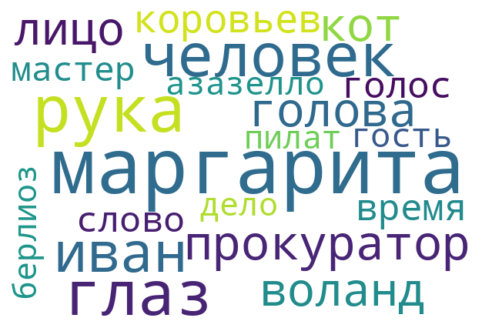

In [ ]:
# Получаем 20 самых частотных сущ
most_common_words = dict(Counter(noun_freq).most_common(20))

# Создаем объект WordCloud
wc = WordCloud(width=600, height=400, background_color='white', max_words=100).generate_from_frequencies(most_common_words)

# Визуализируем облако слов
plt.figure(figsize=(8, 4))
plt.imshow(wc, interpolation="bilinear")
plt.axis("off")
plt.show()

In [ ]:
# Прочитать файл и проверить, что всё хорошо сохранилось (проверить путь)
df1 = pd.read_csv('lemmatized_m_and_m', sep='\t')
df1

,clean
0,однажды весною час небывалый жаркий закат моск...
1,первый иной михаил александрович берлиоз предс...
2,попасть тень зеленеть липа писатель первый дол...
3,следовать отметить первый странность страшный ...
4,дать нарзан попросить берлиоз
...,...
3911,это кончиться ученик отвечать номер сто восемн...
3912,это кончиться кончаться поцелуй лоб
3913,наклоняться иван целовать лоб иван тянуться вс...
3914,луна начинать неистовствовать обрушивать поток...


#### Частнотность слов, связанных с любовью

In [ ]:
def get_word_freq(target_word):
    freq = word_freq.get(target_word, 0)
    print(f"Частота слова '{target_word}': {freq}")
    return freq

target_words = ['любовь','любить','любя','любовный','возлюбленный']
w_counter = 0
for w in target_words:
    freg = get_word_freq(w)
    w_counter += freg

print(w_counter)

Частота слова 'любовь': 8
Частота слова 'любить': 26
Частота слова 'любя': 1
Частота слова 'любовный': 1
Частота слова 'возлюбленный': 0
36


In [ ]:
love_pos_summary = pd.DataFrame([{
    'любовь': get_word_freq('любовь'),
    'любить': get_word_freq('любить')
}])

love_pos_summary

Частота слова 'любовь': 8
Частота слова 'любить': 26


,любовь,любить
0,8,26


### Коллокации

In [ ]:
def analyze_syntagmatic_clean(df, target_word='любовь', window_size=3):
    # Собираем все токены из предобработанного датафрейма
    tokens = []
    for _, row in df.iterrows():
        tokens.extend(str(row['clean']).split())

    # Частеречная разметка через pymorphy3
    tagged = []
    for word in tokens:
        parsed = morph.parse(word)
        if parsed:
            pos = parsed[0].tag.POS or 'UNKN'
        else:
            pos = 'UNKN'
        tagged.append((word, pos))

    # Сбор контекстов целевого слова
    contexts = []
    for i, word in enumerate(tokens):
        if word == target_word:
            start = max(0, i - window_size)
            end = min(len(tokens), i + window_size + 1)
            contexts.append(tagged[start:end])

    # Коллокации через PMI
    bigram_measures = BigramAssocMeasures()
    finder = BigramCollocationFinder.from_words(tokens)
    finder.apply_freq_filter(2)

    scored_collocations = finder.score_ngrams(bigram_measures.pmi)
    target_collocations = [
        (bigram, score) for bigram, score in scored_collocations
        if target_word in bigram
    ]
    target_collocations.sort(key=lambda x: x[1], reverse=True)
    top_collocations = [bigram for bigram, score in target_collocations[:20]]

    return {
        'collocations': top_collocations,
        'contexts': contexts
    }


result = analyze_syntagmatic_clean(df_clean, target_word='любовь')

print("Коллокации с 'любовь':")
for bigram in result['collocations']:
    print(bigram)

print(f"\nНайдено контекстов: {len(result['contexts'])}")
print("Пример контекста:", result['contexts'][0] if result['contexts'] else "—")

Коллокации с 'любовь':

Найдено контекстов: 8
Пример контекста: [('бас', 'NOUN'), ('петь', 'INFN'), ('свой', 'ADJF'), ('любовь', 'NOUN'), ('татьяна', 'NOUN'), ('старинный', 'ADJF'), ('двухэтажный', 'ADJF')]


In [ ]:
result = analyze_syntagmatic_clean(df_clean, target_word='любить')

print("Коллокации с 'любить':")
for bigram in result['collocations']:
    print(bigram)

print(f"\nНайдено контекстов: {len(result['contexts'])}")
print("Пример контекста:", result['contexts'][0] if result['contexts'] else "—")

Коллокации с 'любить':
('любить', 'деньга')
('кто', 'любить')
('любить', 'говорить')
('который', 'любить')

Найдено контекстов: 26
Пример контекста: [('зашептать', 'INFN'), ('коровьев', 'NOUN'), ('желать', 'INFN'), ('любить', 'INFN'), ('гостиница', 'NOUN'), ('сидеть', 'INFN'), ('интурист', 'NOUN')]


In [ ]:
def visualize_results(results):
    plt.figure(figsize=(10, 6))

    if results['collocations']:
        colloc_data = [(c[0], c[1]) for c in results['collocations']]
        colloc_labels = [f"{w1} + {w2}" for w1, w2 in colloc_data]

        # Считаем частоты слов из контекстов правильно
        flat_words = [word for context in results['contexts'] for word, pos in context]
        word_freq_dict = Counter(flat_words)

        colloc_counts = [
            word_freq_dict.get(w1, 1) + word_freq_dict.get(w2, 1)
            for w1, w2 in colloc_data
        ]

        sorted_indices = np.argsort(colloc_counts)
        sorted_labels = [colloc_labels[i] for i in sorted_indices]
        sorted_counts = [colloc_counts[i] for i in sorted_indices]

        plt.barh(sorted_labels, sorted_counts, color='skyblue')
        plt.xlabel('Частота')
        plt.title("Коллокации с лексемой 'любить'", fontsize=14)
        plt.grid(axis='x', linestyle='--', alpha=0.7)
    else:
        plt.text(0.5, 0.5, "Коллокации не найдены", ha='center', va='center', fontsize=14)

    plt.tight_layout()
    plt.show()


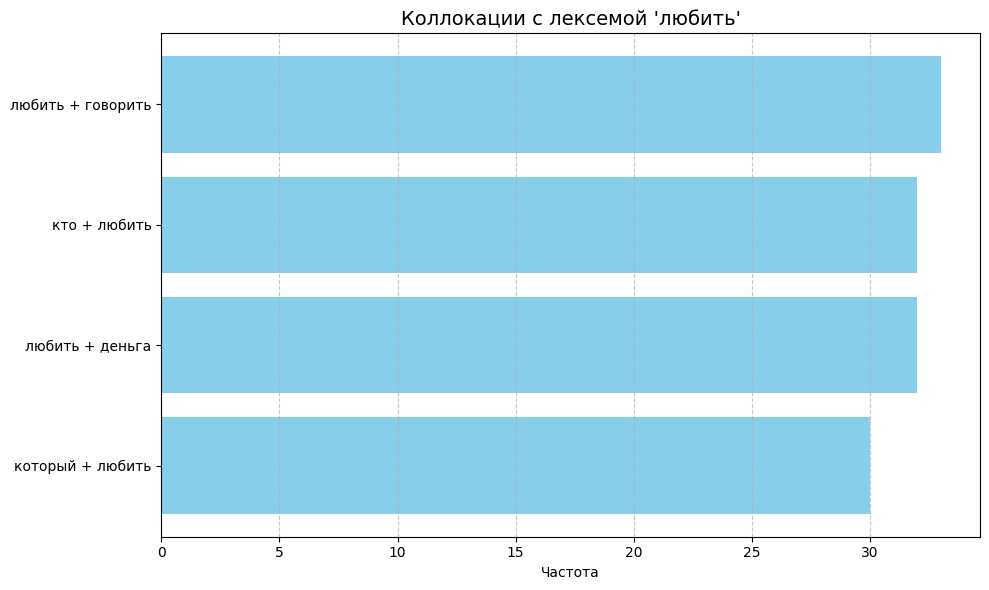

In [ ]:
result = analyze_syntagmatic_clean(df_clean, target_word='любить')
visualize_results(result)
####### проверить частоту

С леммой "любовь" коллокации не найдены, слишком мало контекстов

### Частеречное окружение

In [ ]:
WINDOW = 5

def get_love_contexts_ru(texts: list, window: int = WINDOW):
    noun_context = []
    verb_context = []

    RU_STOP = {'и', 'в', 'на', 'с', 'по', 'к', 'за', 'из', 'не',
               'то', 'а', 'но', 'же', 'бы', 'как', 'что', 'это',
               'он', 'она', 'они', 'мы', 'я', 'ты', 'вы', 'его',
               'ее', 'её', 'их', 'мне', 'меня', 'себя', 'себе',
               'который', 'кто', 'мой', 'твой', 'свой', 'тот',
               'такой', 'весь', 'быть'}

    for text in texts:
        raw_tokens = re.findall(r'[а-яёА-ЯЁa-zA-Z]+', str(text))
        if not raw_tokens:
            continue

        lemmas, pos_tags = [], []
        for w in raw_tokens:
            parsed = morph.parse(w.lower())[0]
            lemmas.append(parsed.normal_form)
            pos_tags.append(parsed.tag.POS)

        for i, (lemma, pos) in enumerate(zip(lemmas, pos_tags)):
            if lemma == 'любовь':
                target_type = 'noun'
            elif lemma == 'любить':
                target_type = 'verb'
            else:
                continue

            left  = lemmas[max(0, i - window): i]
            right = lemmas[i + 1: i + 1 + window]
            neighbors = [l for l in left + right
                         if l not in RU_STOP and len(l) > 2
                         and l not in ('любовь', 'любить')]

            if target_type == 'noun':
                noun_context.extend(neighbors)
            else:
                verb_context.extend(neighbors)

    return noun_context, verb_context

In [ ]:
noun_ctx, verb_ctx = get_love_contexts_ru(df_clean['clean'].tolist())

print(f"Контекстов 'любовь': {len(noun_ctx)}")
print(f"Контекстов 'любить': {len(verb_ctx)}")
print(f"\nТоп-20 слов рядом с любовь (сущ.): {Counter(noun_ctx).most_common(20)}")
print(f"\nТоп-20 слов рядом с любить (глаг.): {Counter(verb_ctx).most_common(20)}")

Контекстов 'любовь': 58
Контекстов 'любить': 167

Топ-20 слов рядом с любовь (сущ.): [('стыдно', 2), ('тяжёлый', 1), ('бас', 1), ('петь', 1), ('татьяна', 1), ('неожиданный', 1), ('слеза', 1), ('правый', 1), ('рукав', 1), ('продолжать', 1), ('выскочить', 1), ('земля', 1), ('выскакивать', 1), ('убийца', 1), ('поразить', 1), ('мгновенно', 1), ('знать', 1), ('день', 1), ('час', 1), ('свет', 1)]

Топ-20 слов рядом с любить (глаг.): [('человек', 5), ('деньга', 5), ('говорить', 4), ('сказать', 3), ('знать', 2), ('коровьев', 2), ('сидеть', 2), ('человечество', 2), ('жизнь', 2), ('женщина', 2), ('друг', 2), ('сад', 2), ('считать', 2), ('самый', 2), ('последний', 2), ('рада', 2), ('моляще', 2), ('пёс', 2), ('должный', 2), ('разделять', 2)]


In [ ]:
TOP_N = 20

ru_noun_freq = Counter(noun_ctx).most_common(TOP_N)
ru_verb_freq = Counter(verb_ctx).most_common(TOP_N)

# Вывод таблиц
for label, freq in [('RU любить-NOUN', ru_noun_freq),
                     ('RU любить-VERB', ru_verb_freq)]:
    df_freq = pd.DataFrame(freq, columns=['word', 'freq'])
    print(f"\n=== {label} ===")
    print(df_freq.to_string(index=False))


=== RU любить-NOUN ===
       word  freq
     стыдно     2
    тяжёлый     1
        бас     1
       петь     1
    татьяна     1
неожиданный     1
      слеза     1
     правый     1
      рукав     1
 продолжать     1
  выскочить     1
      земля     1
выскакивать     1
     убийца     1
   поразить     1
  мгновенно     1
      знать     1
       день     1
        час     1
       свет     1

=== RU любить-VERB ===
        word  freq
     человек     5
      деньга     5
    говорить     4
     сказать     3
       знать     2
    коровьев     2
      сидеть     2
человечество     2
       жизнь     2
     женщина     2
        друг     2
         сад     2
     считать     2
       самый     2
   последний     2
        рада     2
      моляще     2
         пёс     2
     должный     2
   разделять     2


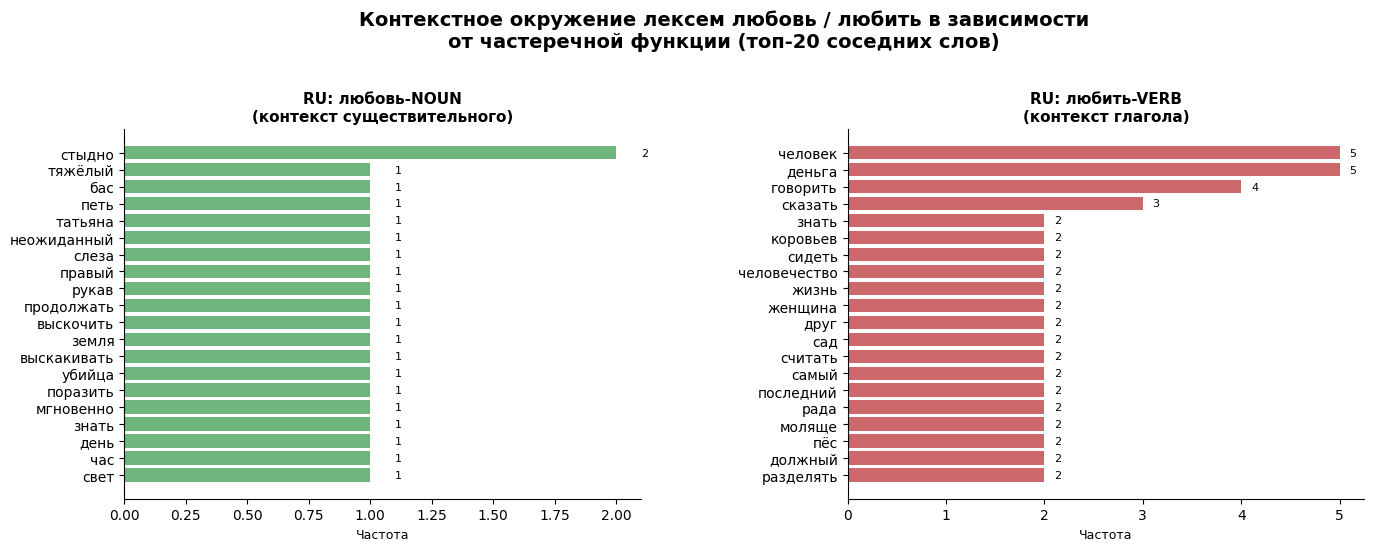

In [ ]:
fig = plt.figure(figsize=(16, 12))
fig.suptitle('Контекстное окружение лексем любовь / любить в зависимости\nот частеречной функции (топ-20 соседних слов)',
             fontsize=14, fontweight='bold', y=0.98)

gs = GridSpec(2, 2, figure=fig, hspace=0.5, wspace=0.4)

panels = [
    (ru_noun_freq, 'RU: любовь-NOUN\n(контекст существительного)', '#55A868', gs[0, 0]),
    (ru_verb_freq, 'RU: любить-VERB\n(контекст глагола)',           '#C44E52', gs[0, 1]),

]

for freq_data, title, color, grid_pos in panels:
    ax = fig.add_subplot(grid_pos)
    if not freq_data:
        ax.text(0.5, 0.5, 'Нет данных', ha='center', va='center', transform=ax.transAxes)
        ax.set_title(title, fontsize=11, fontweight='bold')
        continue
    words  = [w for w, _ in freq_data][::-1]
    counts = [c for _, c in freq_data][::-1]
    bars = ax.barh(words, counts, color=color, alpha=0.85)
    ax.set_title(title, fontsize=11, fontweight='bold')
    ax.set_xlabel('Частота', fontsize=9)
    # Подписи значений
    for bar, val in zip(bars, counts):
        ax.text(val + 0.1, bar.get_y() + bar.get_height()/2,
                str(val), va='center', fontsize=8)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.show()

## **Обучение векторной модели**

In [ ]:
cores = multiprocessing.cpu_count()

In [ ]:
workers = cores - 1  # Оставь одно ядро для ОС

In [ ]:
fasttext_model = FastText(
    sentences=sentences,
    min_count=3,
    window=6,
    vector_size=100,
    sg=1,
    sample=1e-4,
    alpha=0.025,
    min_alpha=1e-3,
    negative=10,
    workers=workers,
    min_n=3,
    max_n=5,
    epochs=30,
    seed=42
)

In [ ]:
list_sentences = list(sentences)  # иногда это помогает преобразовать обратно
print(list_sentences[:3])

[['однажды', 'весною', 'час', 'небывалый', 'жаркий', 'закат', 'москва', 'патриарший_пруд', 'появиться', 'гражданин', 'первый', 'одетый', 'летний', 'серенький', 'пара', 'маленький', 'рост', 'упитанный', 'лысый', 'приличный', 'шляпа', 'пирожок', 'нести', 'рука', 'выбрить', 'лицо', 'помещаться', 'сверхъестественный', 'размер', 'очки', 'чёрный', 'рогов', 'оправа', 'второй', 'плечистый', 'рыжеватый', 'вихрастый', 'молодой_человек', 'заломить', 'затылок', 'клетчатый', 'кепка', 'ковбойка', 'жёваный', 'белый', 'брюки', 'чёрный', 'тапочки'], ['первый', 'иной', 'михаил_александрович', 'берлиоз', 'председатель', 'правление', 'один', 'крупный', 'московский', 'литературный', 'ассоциация', 'сокращённо', 'именовать', 'массолит', 'редактор', 'толстой', 'художественный', 'журнал', 'молодой', 'спутник', 'поэт', 'иван_николаевич', 'понырёв', 'пишущий', 'псевдоним', 'бездомный'], ['попасть', 'тень', 'зеленеть', 'липа', 'писатель', 'первый', 'долг', 'броситься', 'пестро', 'раскрасить', 'будочка', 'надпись'

Проверяем качество работы модели

* Ближайшие соседние векторы к векторам лексем в пространстве эмбеддингов FastText

In [ ]:
fasttext_model.wv.most_similar(positive=["любовь"])

[('галлюцинация', 0.8755658864974976),
 ('отколоть', 0.8606361746788025),
 ('любовник', 0.8526613712310791),
 ('вздох', 0.8436274528503418),
 ('сухо', 0.8395094275474548),
 ('ухо', 0.8385652899742126),
 ('гусь', 0.8379554152488708),
 ('любой', 0.8358740210533142),
 ('алло', 0.8357365727424622),
 ('отрывисто', 0.8354467153549194)]

In [ ]:
fasttext_model.wv.most_similar(positive=["любить"])

[('влюбить', 0.9677994251251221),
 ('возлюбить', 0.9485784769058228),
 ('убить', 0.915378212928772),
 ('хамить', 0.91121906042099),
 ('осмыслить', 0.904254674911499),
 ('молить', 0.8960794806480408),
 ('сулить', 0.8764157891273499),
 ('ошеломить', 0.86985844373703),
 ('томить', 0.8680412173271179),
 ('вспылить', 0.8673109412193298)]

In [ ]:
fasttext_model.wv.most_similar(positive=["маргарита"])

[('дирижёр', 0.848200261592865),
 ('галопом', 0.8465623259544373),
 ('пухлый', 0.8426153063774109),
 ('седло', 0.8420507311820984),
 ('африканец', 0.8412941694259644),
 ('мазь', 0.8370112180709839),
 ('гелла', 0.8330683708190918),
 ('нагота', 0.8218604922294617),
 ('ампула', 0.8213310241699219),
 ('мастер', 0.8209648728370667)]

In [ ]:
fasttext_model.wv.most_similar(positive=["мастер"])

[('марго', 0.8711813688278198),
 ('укол', 0.8600814938545227),
 ('118', 0.827049195766449),
 ('маргарита', 0.8209648728370667),
 ('тсс', 0.8053117394447327),
 ('мазь', 0.8027356266975403),
 ('мгла', 0.7953037619590759),
 ('латынь', 0.7921645045280457),
 ('испуг', 0.7910349369049072),
 ('юноша', 0.7899050116539001)]

* Ближайшие соседние векторы к результирующему вектору
*мастер + маргарита − любовь* в пространстве эмбеддингов FastText


In [ ]:
fasttext_model.wv.most_similar(positive=["маргарита", "мастер"],
                               negative=["любовь"])

[('штора', 0.7217497229576111),
 ('нагота', 0.7214390635490417),
 ('навзничь', 0.7034788131713867),
 ('седло', 0.7013474106788635),
 ('ветер', 0.6991624236106873),
 ('диск', 0.6983352899551392),
 ('осколок', 0.6961373686790466),
 ('гелла', 0.6947206854820251),
 ('диван', 0.6907803416252136),
 ('африканец', 0.686406135559082)]

* Семантическая близость пары

In [ ]:
print(fasttext_model.wv.similarity("мастер", "маргарита"))

0.8209649


In [ ]:
print(fasttext_model.wv.similarity("любовь", "маргарита"))

0.64925295


In [ ]:
print(fasttext_model.wv.similarity("любовь", "мастер"))

0.6738364


## Моделирование лексико-семантического поля

### Один график, но любовь и любить отдельно

In [ ]:
RU_STOP = {
    'и', 'в', 'на', 'с', 'по', 'к', 'за', 'из', 'не', 'то', 'а', 'но',
    'же', 'бы', 'как', 'что', 'это', 'он', 'она', 'они', 'мы', 'я', 'ты',
    'вы', 'его', 'её', 'их', 'мне', 'меня', 'себя', 'себе', 'который',
    'кто', 'мой', 'твой', 'свой', 'тот', 'такой', 'весь', 'быть', 'уже',
    'ещё', 'так', 'вот', 'тут', 'там', 'где', 'когда', 'очень', 'сам'
}


def is_russian(word: str) -> bool:
    """Проверяет, что слово состоит только из кириллицы."""
    return all('а' <= ch <= 'я' or ch == 'ё' for ch in word.lower())

def cluster_basewords(model, basewords=('любовь', 'любить'), topn=80, n_clusters=6, min_len=3):
    """
    Выделяет ближайшие к каждому из basewords слова и кластеризует объединённый список.

    Возвращает:
    words       – список слов,
    vectors     – исходные векторы (d-мерные),
    labels      – метки кластеров (по 2D),
    vectors_2d  – векторы после t-SNE (2D),
    source_map  – dict {слово: 'любовь' | 'любить' | 'оба'} для раскраски на графике.
    """
    missing = [w for w in basewords if w not in model.wv.key_to_index]
    if missing:
        print(f"Не найдено в словаре модели: {missing}")
        return None, None, None, None, None

    # Собираем похожие слова отдельно для каждого базового слова
    sets = {}
    for bw in basewords:
        sets[bw] = set(
            word for word, _ in model.wv.most_similar(bw, topn=topn)
        )

    # source_map: откуда пришло каждое слово
    source_map = {}
    for bw in basewords:
        for w in sets[bw]:
            if w in source_map:
                source_map[w] = 'оба'
            else:
                source_map[w] = bw
    for bw in basewords:
        source_map[bw] = 'оба'   # сами базовые слова — общие

    # Объединяем и фильтруем
    all_words = list(basewords) + list(source_map.keys() - set(basewords))
    words = [
        w for w in all_words
        if w in model.wv.key_to_index
        and len(w) >= min_len
        and is_russian(w)
        and w not in RU_STOP
    ]
    # Убираем дубликаты, сохраняя порядок
    seen = set()
    words = [w for w in words if not (w in seen or seen.add(w))]

    if len(words) < n_clusters:
        print(f"Слишком мало слов ({len(words)}) для {n_clusters} кластеров. "
              f"Увеличь topn или уменьши n_clusters.")
        return None, None, None, None, None

    vectors = np.array([model.wv[w] for w in words])

    tsne = TSNE(
        n_components=2,
        random_state=42,
        perplexity=min(25, len(vectors) - 1),
        max_iter=1000,
        learning_rate=200,
        n_jobs=-1
    )
    vectors_2d = tsne.fit_transform(vectors)

    kmeans = KMeans(n_clusters=min(n_clusters, len(words)), n_init=10, random_state=42)
    labels = kmeans.fit_predict(vectors_2d)

    return words, vectors, labels, vectors_2d, source_map

In [ ]:
words, vectors, labels, vectors_2d, source_map = cluster_basewords(
    fasttext_model, basewords=('любовь', 'любить'), topn=80, n_clusters=6
)



> Метрики считаем по vectors исходной размерности, vectors2d нужны только для визуализации!

In [ ]:
# Подбор k — по исходным векторам
for k in range(2, 11):
    kmeans = KMeans(n_clusters=k, n_init=10, random_state=42)
    labels_k = kmeans.fit_predict(vectors)  # ← исходные, не vectors2d
    score = silhouette_score(vectors, labels_k, metric='cosine')
    print(f"k={k}: silhouette = {score:.3f}")

# Финальная кластеризация с лучшим k — тоже по исходным
kmeans_final = KMeans(n_clusters=3, n_init=10, random_state=42)
labels_final = kmeans_final.fit_predict(vectors)  # ← исходные
sil = silhouette_score(vectors, labels_final, metric='cosine')
db  = davies_bouldin_score(vectors, labels_final)

k=2: silhouette = 0.515
k=3: silhouette = 0.279
k=4: silhouette = 0.273
k=5: silhouette = 0.272
k=6: silhouette = 0.124
k=7: silhouette = 0.130
k=8: silhouette = 0.154
k=9: silhouette = 0.145
k=10: silhouette = 0.144


График, где три вида точек:
* синие - относятся только к `любовь`
* оранжевые - относятся только к `любить`
* зеленые - относятся к `любовь` и `любить`

In [ ]:
SOURCE_COLORS = {
    'любовь': '#4C72B0',   # синий
    'любить': '#DD8452',   # оранжевый
    'оба':    '#55A868',   # зелёный
}

def visualize_semantic_field_ru(model, basewords=('любовь', 'любить'), topn=80, n_clusters=6):
    words, vectors, labels, vectors_2d, source_map = cluster_basewords(
        model, basewords=basewords, topn=topn, n_clusters=n_clusters
    )
    if words is None:
        return

    fig, ax = plt.subplots(figsize=(18, 13))

    # Цвет каждой точки по источнику (любовь / любить / оба)
    point_colors = [SOURCE_COLORS.get(source_map.get(w, 'оба'), '#888888') for w in words]

    ax.scatter(
        vectors_2d[:, 0], vectors_2d[:, 1],
        c=point_colors,
        alpha=0.85, s=110, edgecolors='black', linewidth=0.4, zorder=2
    )

    # Подписи слов
    texts = []
    for i, word in enumerate(words):
        if word in basewords:
            t = ax.text(
                vectors_2d[i, 0], vectors_2d[i, 1], word,
                fontsize=15, fontweight='bold', color='darkred',
                bbox=dict(facecolor='lightyellow', alpha=1.0,
                          edgecolor='red', boxstyle='round,pad=0.5', linewidth=2)
            )
        else:
            t = ax.text(
                vectors_2d[i, 0], vectors_2d[i, 1], word,
                fontsize=11,
                bbox=dict(facecolor='white', alpha=0.75,
                          edgecolor='grey', boxstyle='round,pad=0.3')
            )
        texts.append(t)

    adjust_text(
        texts,
        arrowprops=dict(arrowstyle='->', color='gray', lw=0.5),
        force_points=(0.5, 0.5),
        force_text=(0.8, 0.8),
        expand_points=(1.5, 1.5),
        ax=ax
    )

    # Легенда по источнику слова
    legend_elements = [
        mpatches.Patch(facecolor=SOURCE_COLORS['любовь'], edgecolor='black',
                       label=f'Ближайшие к «любовь»'),
        mpatches.Patch(facecolor=SOURCE_COLORS['любить'], edgecolor='black',
                       label=f'Ближайшие к «любить»'),
        mpatches.Patch(facecolor=SOURCE_COLORS['оба'],    edgecolor='black',
                       label='Общие (пересечение)'),
    ]
    ax.legend(handles=legend_elements, title='Источник слова',
              loc='lower right', framealpha=0.9, fontsize=11, title_fontsize=12)

    title_words = ' + '.join(f'«{w}»' for w in basewords)
    plt.title(f'Лексико-семантическое поле: {title_words}',
              fontsize=18, fontweight='bold', pad=15)
    ax.set_axis_off()
    plt.tight_layout()
    plt.show()


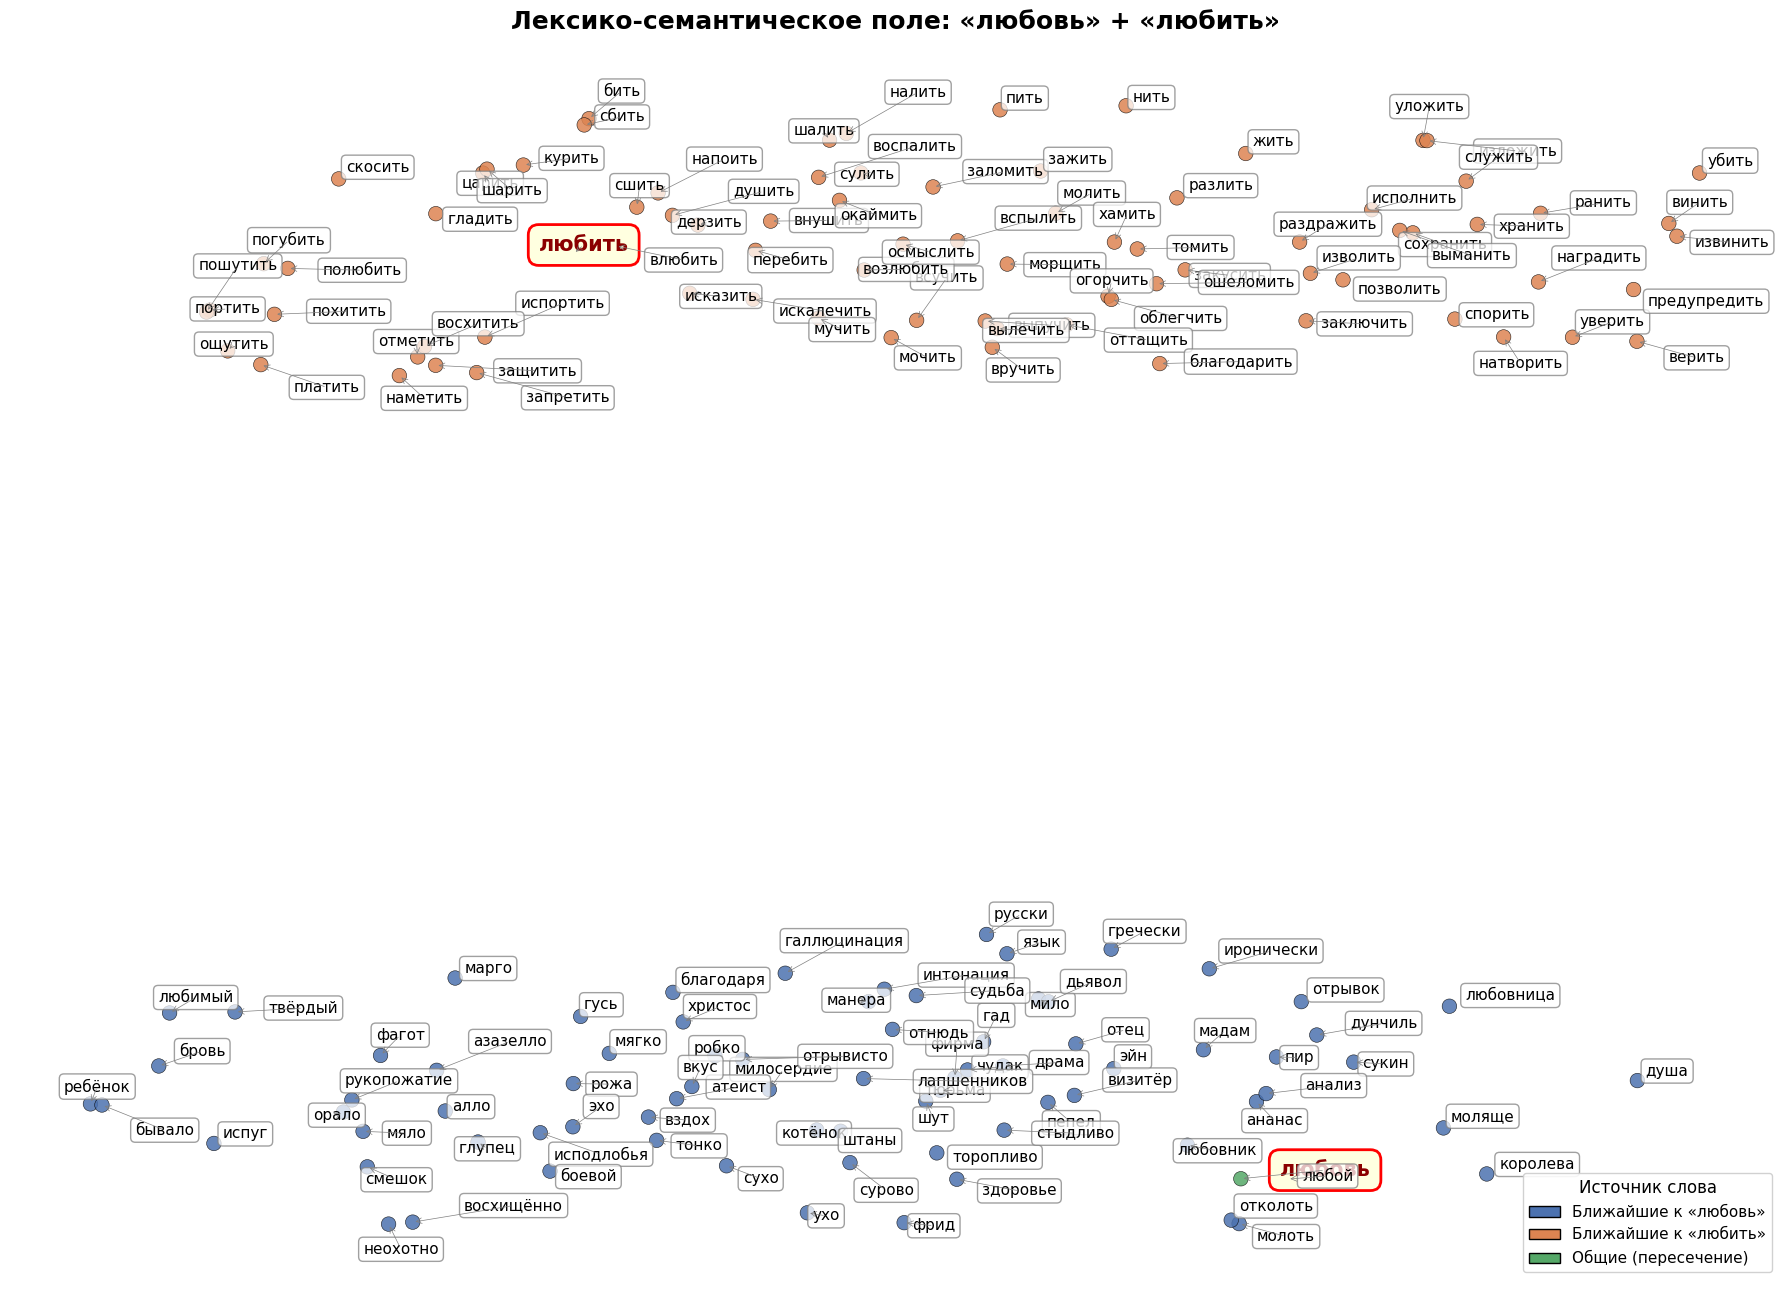

In [ ]:
visualize_semantic_field_ru(fasttext_model, basewords=('любовь', 'любить'), topn=80, n_clusters=6)

В этом варианте у каждого подграфика выделяются свои кластеры

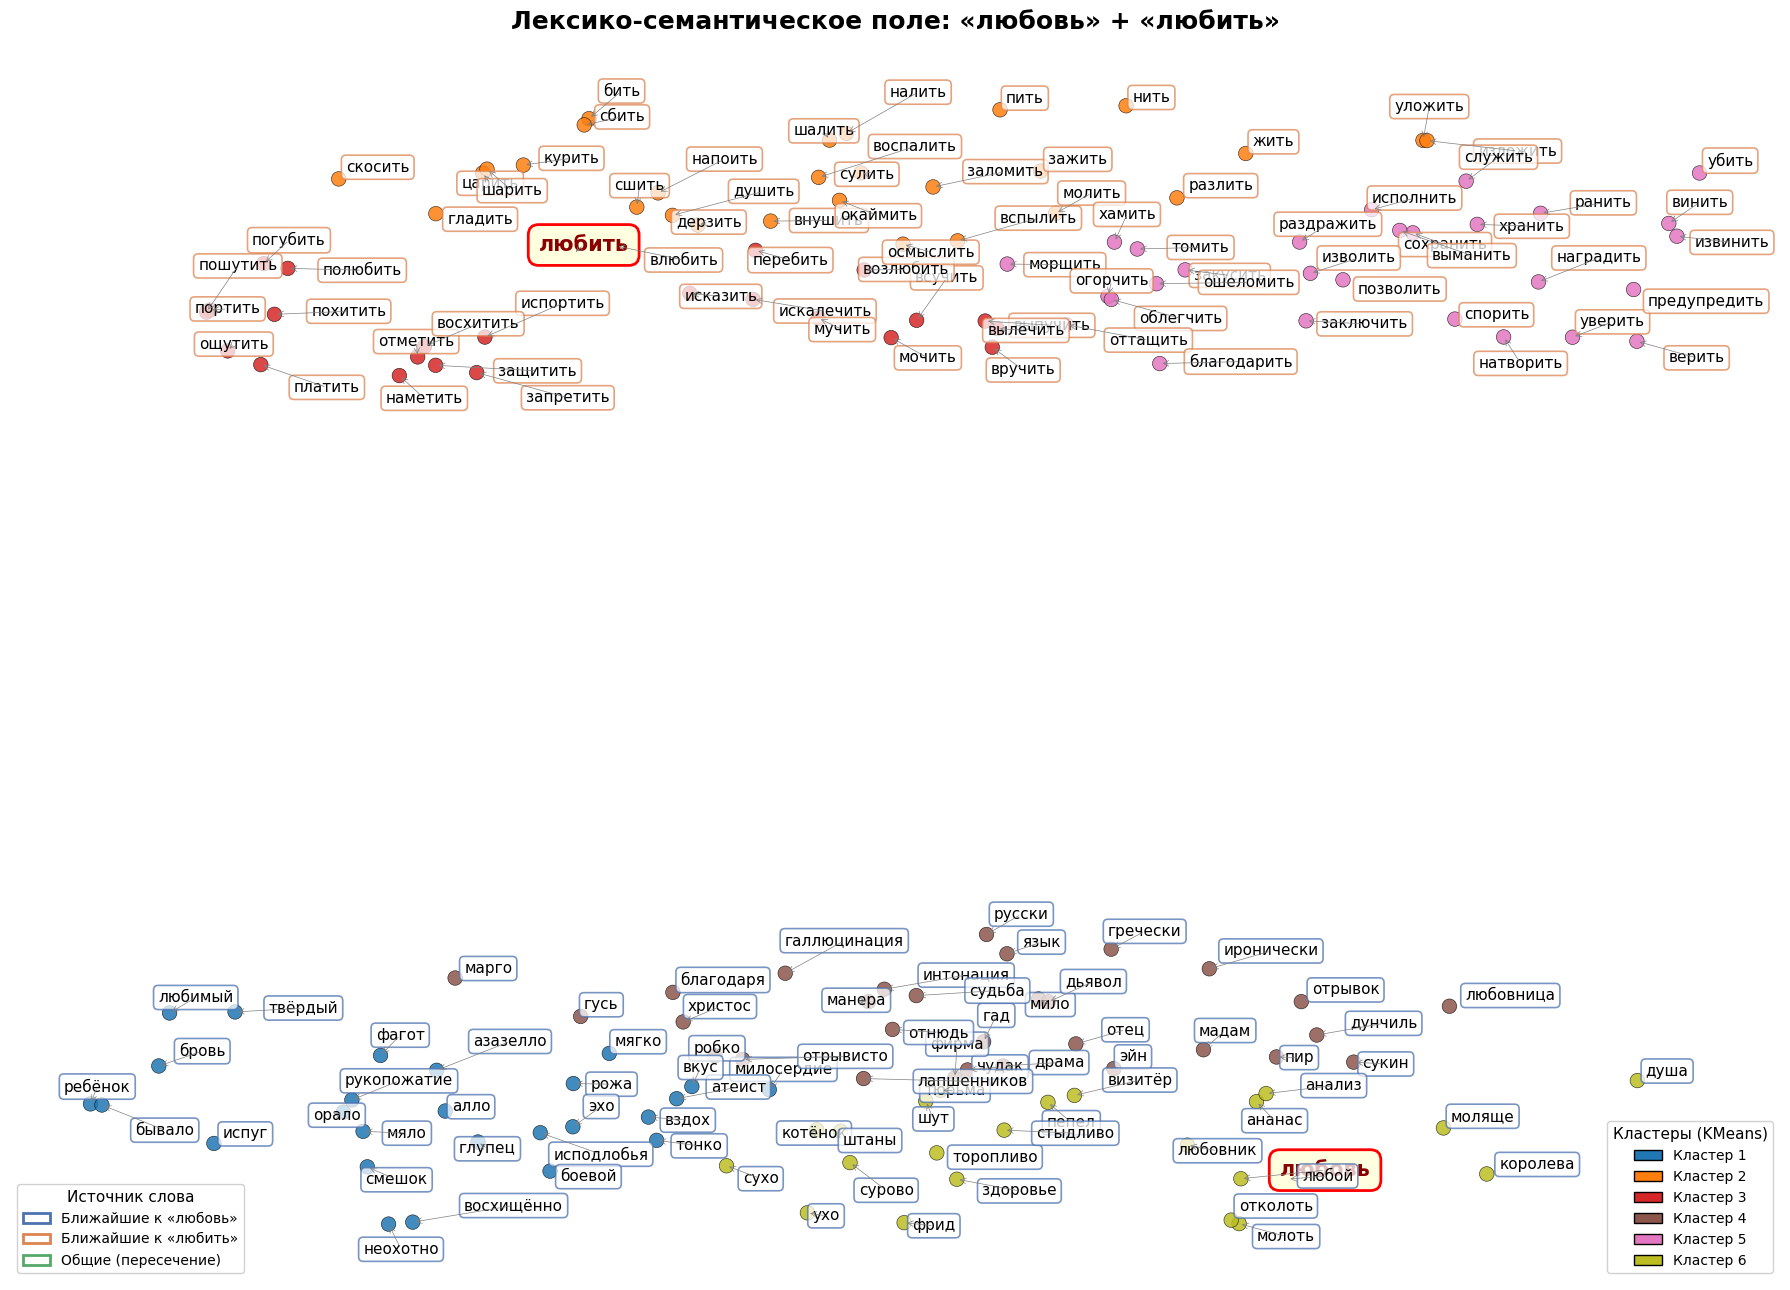

In [ ]:
def visualize_semantic_field_ru(model, basewords=('любовь', 'любить'), topn=80, n_clusters=6):
    words, vectors, labels, vectors_2d, source_map = cluster_basewords(
        model, basewords=basewords, topn=topn, n_clusters=n_clusters
    )
    if words is None:
        return

    fig, ax = plt.subplots(figsize=(18, 13))

    # Цвет точек — по кластеру KMeans
    cmap = plt.cm.tab10
    point_colors = [cmap(label / n_clusters) for label in labels]

    ax.scatter(
        vectors_2d[:, 0], vectors_2d[:, 1],
        c=point_colors,
        alpha=0.85, s=110, edgecolors='black', linewidth=0.4, zorder=2
    )

    # Маркер источника — форма обводки подписи
    SOURCE_EDGE = {
        'любовь': '#4C72B0',  # синяя рамка
        'любить': '#DD8452',  # оранжевая рамка
        'оба':    '#55A868',  # зелёная рамка
    }

    texts = []
    for i, word in enumerate(words):
        edge_color = SOURCE_EDGE.get(source_map.get(word, 'оба'), 'grey')

        if word in basewords:
            t = ax.text(
                vectors_2d[i, 0], vectors_2d[i, 1], word,
                fontsize=15, fontweight='bold', color='darkred',
                bbox=dict(facecolor='lightyellow', alpha=1.0,
                          edgecolor='red', boxstyle='round,pad=0.5', linewidth=2)
            )
        else:
            t = ax.text(
                vectors_2d[i, 0], vectors_2d[i, 1], word,
                fontsize=11,
                bbox=dict(facecolor='white', alpha=0.75,
                          edgecolor=edge_color, boxstyle='round,pad=0.3', linewidth=1.2)
            )
        texts.append(t)

    adjust_text(
        texts,
        arrowprops=dict(arrowstyle='->', color='gray', lw=0.5),
        force_points=(0.5, 0.5),
        force_text=(0.8, 0.8),
        expand_points=(1.5, 1.5),
        ax=ax
    )

    # Легенда 1 — кластеры KMeans (цвет заливки точки)
    cluster_legend = [
        mpatches.Patch(facecolor=cmap(i / n_clusters), edgecolor='black',
                       label=f'Кластер {i + 1}')
        for i in range(n_clusters)
    ]
    legend1 = ax.legend(handles=cluster_legend, title='Кластеры (KMeans)',
                        loc='lower right', framealpha=0.9,
                        fontsize=10, title_fontsize=11)
    ax.add_artist(legend1)

    # Легенда 2 — источник слова (цвет рамки подписи)
    source_legend = [
        mpatches.Patch(facecolor='white', edgecolor='#4C72B0', linewidth=2,
                       label='Ближайшие к «любовь»'),
        mpatches.Patch(facecolor='white', edgecolor='#DD8452', linewidth=2,
                       label='Ближайшие к «любить»'),
        mpatches.Patch(facecolor='white', edgecolor='#55A868', linewidth=2,
                       label='Общие (пересечение)'),
    ]
    ax.legend(handles=source_legend, title='Источник слова',
              loc='lower left', framealpha=0.9,
              fontsize=10, title_fontsize=11)

    title_words = ' + '.join(f'«{w}»' for w in basewords)
    plt.title(f'Лексико-семантическое поле: {title_words}',
              fontsize=18, fontweight='bold', pad=15)
    ax.set_axis_off()
    plt.tight_layout()
    plt.show()


# Запуск
visualize_semantic_field_ru(fasttext_model, basewords=('любовь', 'любить'), topn=80, n_clusters=6)

### По каждому слову отдельно

In [ ]:
def cluster_baseword_ru(model, baseword, topn=80, n_clusters=3, min_len=3):
    if baseword not in model.wv.key_to_index:
        print(f"'{baseword}' не найдено в словаре модели.")
        return None, None, None, None

    similar = [word for word, _ in model.wv.most_similar(baseword, topn=topn)]
    all_words = [baseword] + similar

    words = []
    seen = set()
    for w in all_words:
        if (w not in seen
                and w in model.wv.key_to_index
                and len(w) >= min_len
                and is_russian(w)
                and w not in RU_STOP):
            words.append(w)
            seen.add(w)

    if len(words) < n_clusters:
        print(f"Слишком мало слов ({len(words)}) для {n_clusters} кластеров.")
        return None, None, None, None

    vectors = np.array([model.wv[w] for w in words])

    tsne = TSNE(
        n_components=2, random_state=42,
        perplexity=min(25, len(vectors) - 1),
        max_iter=1000, learning_rate=200, n_jobs=-1
    )
    vectors_2d = tsne.fit_transform(vectors)

    kmeans = KMeans(n_clusters=min(n_clusters, len(words)), n_init=10, random_state=42)
    labels = kmeans.fit_predict(vectors_2d)

    return words, vectors, labels, vectors_2d

In [ ]:
def visualize_semantic_field_ru(model, baseword, topn=80, n_clusters=6):
    words, vectors, labels, vectors_2d = cluster_baseword_ru(
        model, baseword, topn=topn, n_clusters=n_clusters
    )
    if words is None:
        return

    # Фиксированная палитра — одинаковая формула для точек и легенды
    cmap = plt.cm.tab10
    COLORS = [cmap(i / (n_clusters - 1)) for i in range(n_clusters)]
    point_colors = [COLORS[label] for label in labels]

    fig, ax = plt.subplots(figsize=(18, 13))

    ax.scatter(
        vectors_2d[:, 0], vectors_2d[:, 1],
        c=point_colors,
        alpha=0.85, s=110, edgecolors='black', linewidth=0.4, zorder=2
    )

    texts = []
    for i, word in enumerate(words):
        if word == baseword:
            t = ax.text(
                vectors_2d[i, 0], vectors_2d[i, 1], word,
                fontsize=15, fontweight='bold', color='darkred',
                bbox=dict(facecolor='lightyellow', alpha=1.0,
                          edgecolor='red', boxstyle='round,pad=0.5', linewidth=2)
            )
        else:
            t = ax.text(
                vectors_2d[i, 0], vectors_2d[i, 1], word,
                fontsize=11,
                bbox=dict(facecolor='white', alpha=0.75,
                          edgecolor='grey', boxstyle='round,pad=0.3')
            )
        texts.append(t)

    adjust_text(
        texts,
        arrowprops=dict(arrowstyle='->', color='gray', lw=0.5),
        force_points=(0.5, 0.5),
        force_text=(0.8, 0.8),
        expand_points=(1.5, 1.5),
        ax=ax
    )

    legend_elements = [
        mpatches.Patch(facecolor=COLORS[i], edgecolor='black', label=f'Кластер {i + 1}')
        for i in range(n_clusters)
    ]
    ax.legend(handles=legend_elements, title='Кластеры (KMeans)',
              loc='lower right', framealpha=0.9, fontsize=10, title_fontsize=11)

    plt.title(f"Лексико-семантическое поле слова «{baseword}»",
              fontsize=18, fontweight='bold', pad=15)
    ax.set_axis_off()
    plt.tight_layout()
    plt.show()

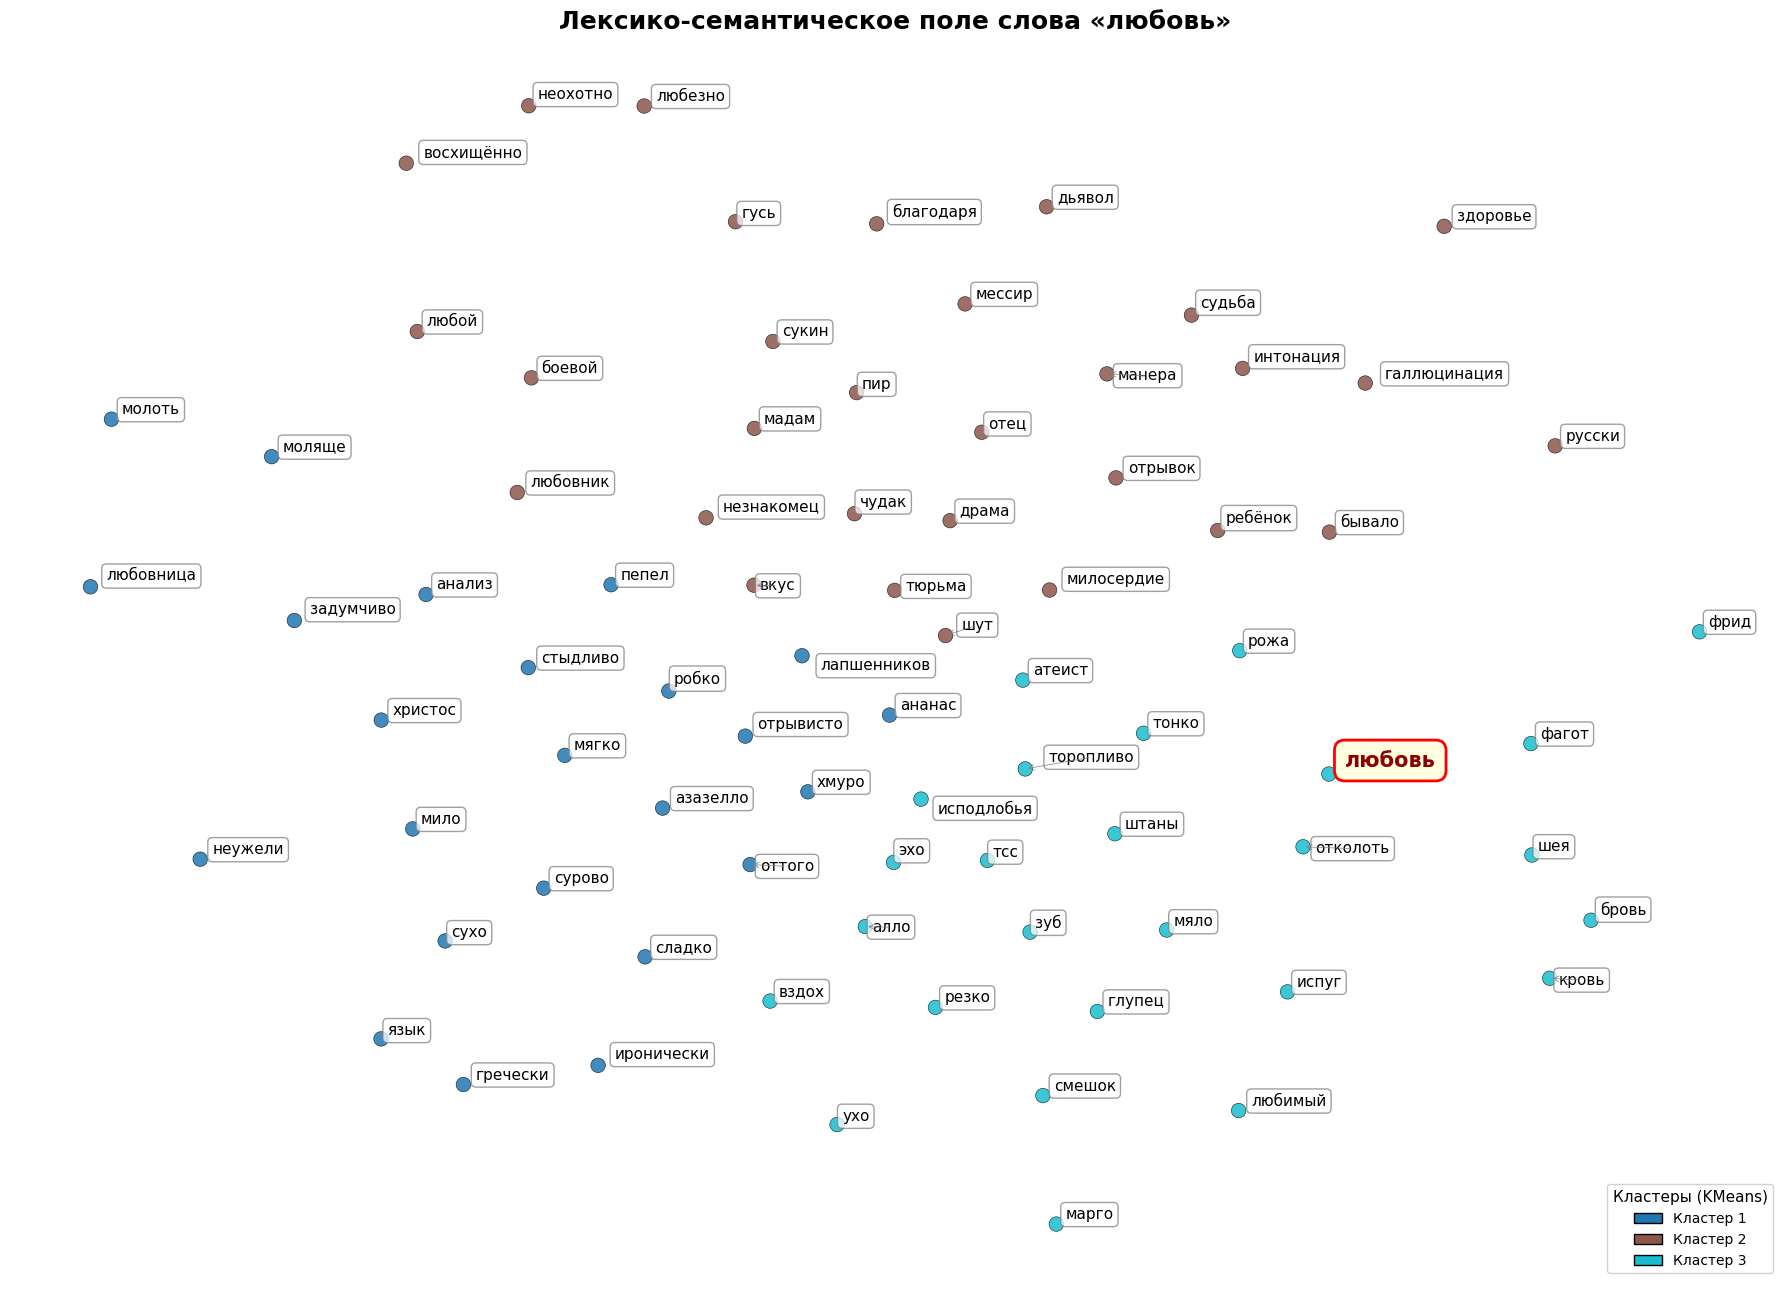

In [ ]:
visualize_semantic_field_ru(fasttext_model, baseword='любовь', topn=80, n_clusters=3)

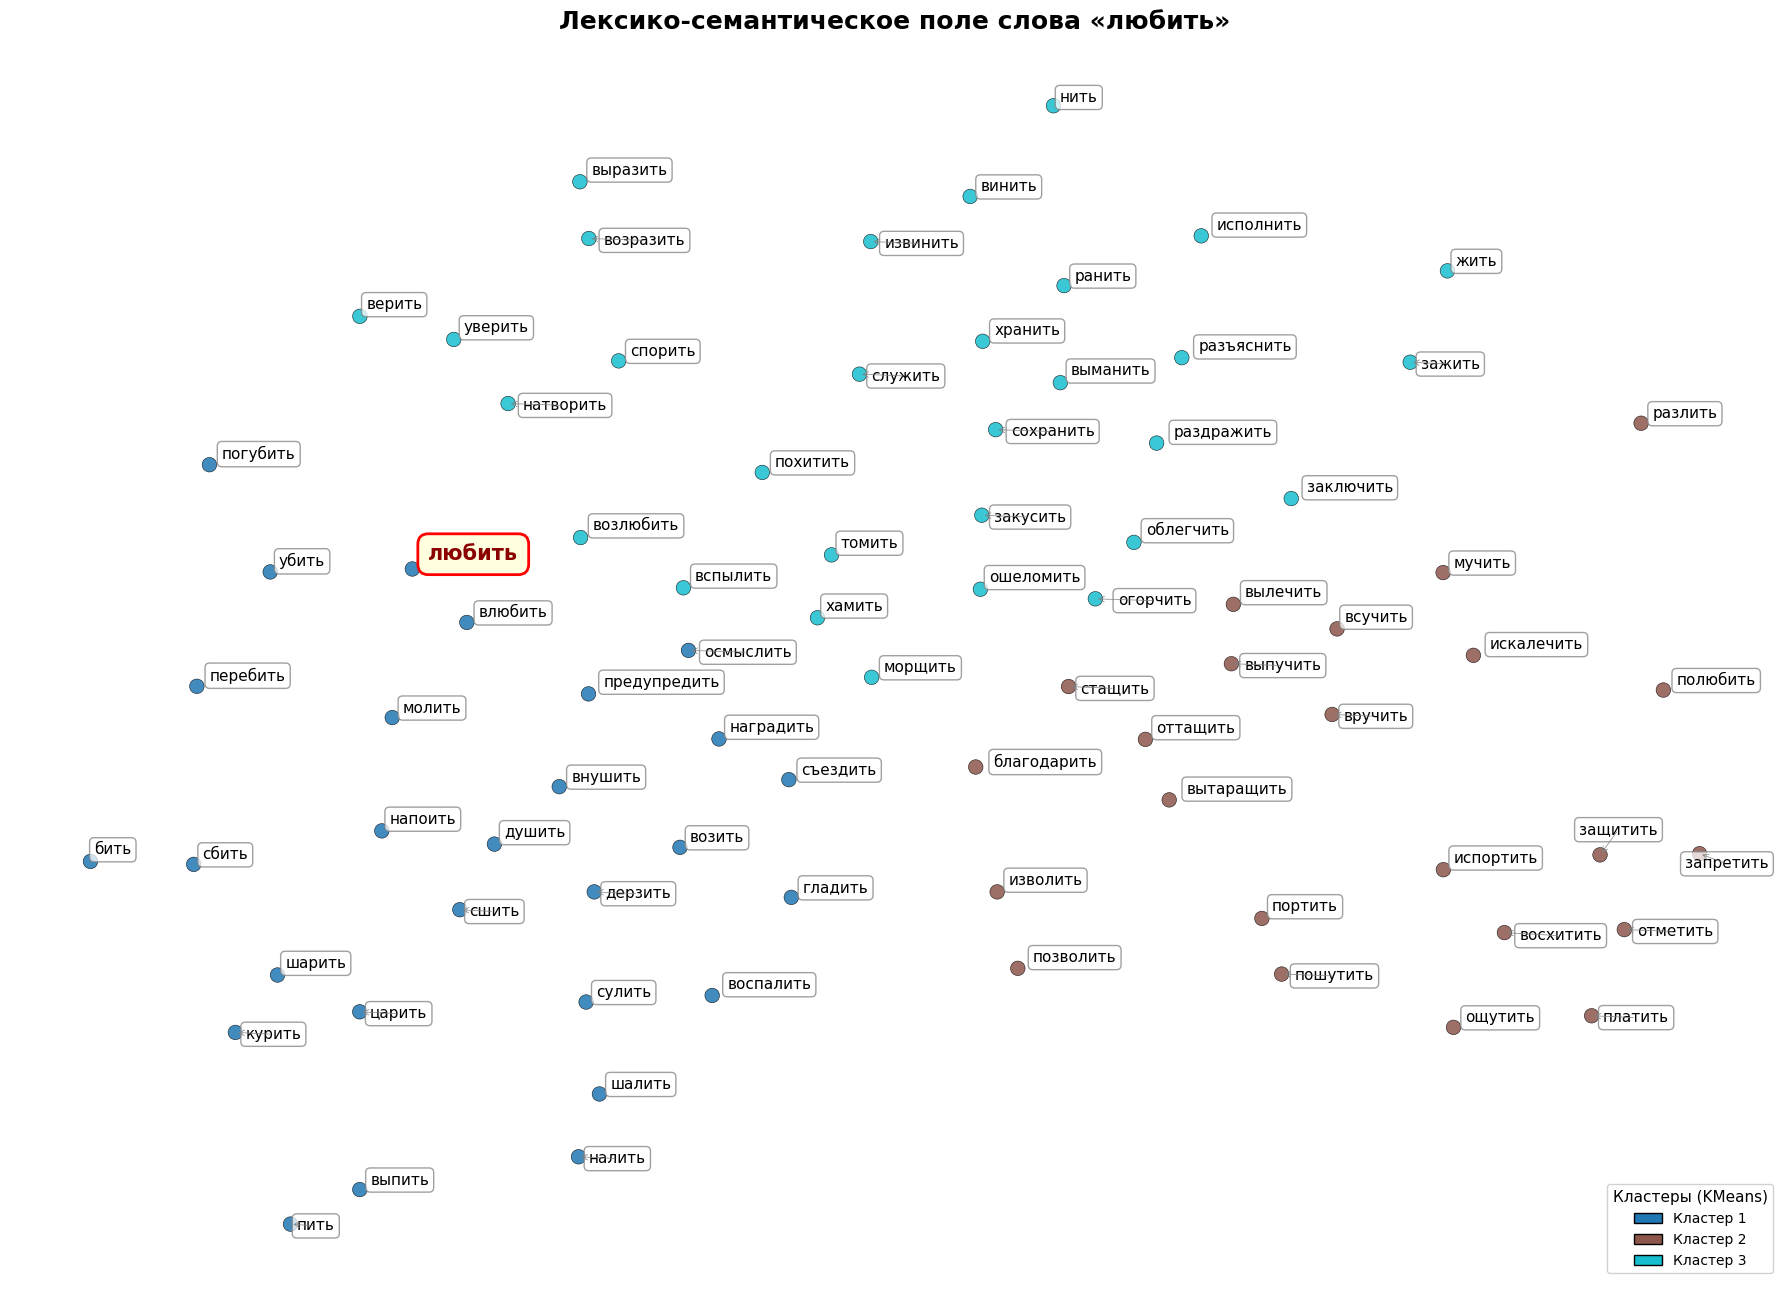

In [ ]:
visualize_semantic_field_ru(fasttext_model, baseword='любить', topn=80, n_clusters=3)

### Метрики



> Метрики считаем по vectors исходной размерности, vectors2d нужны только для визуализации!

In [ ]:
# model – это обученный FastText (например, из visualize_semantic_field_from_df)
words, vectors, labels, vectors2d = cluster_baseword_ru(fasttext_model, 'любовь', topn=80)

if words is not None:
    # Метрики считаем по тем данным, где делали кластеризацию – по vectors2d
    sil = silhouette_score(vectors, labels, metric='cosine')
    db  = davies_bouldin_score(vectors, labels)

Silhouette score: 0.066
Davies-Bouldin Index: 3.306


In [ ]:
print(f"Финальные метрики 'любовь' (k=3):")
# 1. Silhouette Score (чем ближе к 1 — тем лучше кластеры)
print(f"Silhouette score: {sil:.3f}")

# 2. Davies-Bouldin Index (чем меньше — тем лучше)
print(f"Davies-Bouldin Index: {db:.3f}")

Финальные метрики 'любовь' (k=3):
Silhouette score: 0.066
Davies-Bouldin Index: 3.306


In [ ]:
print(f"Финальные метрики 'любить' (k=3):")
# 1. Silhouette Score (чем ближе к 1 — тем лучше кластеры)
print(f"Silhouette score: {sil:.3f}")

# 2. Davies-Bouldin Index (чем меньше — тем лучше)
print(f"Davies-Bouldin Index: {db:.3f}")

Финальные метрики 'любить' (k=3):
Silhouette score: 0.164
Davies-Bouldin Index: 2.530


In [ ]:
# words, vectors, labels — из cluster_baseword
words, vectors, labels, vectors_2d = cluster_baseword_ru(fasttext_model, 'любить', topn=80, n_clusters=3)

# concept_vector — вектор слова 'love'
concept_vector = fasttext_model.wv['любить']

# 3. Средняя косинусная близость внутри каждого кластера
print("\nСредняя косинусная близость внутри кластеров:")
for cluster_id in sorted(set(labels)):
    cluster_vectors = vectors[labels == cluster_id]
    if len(cluster_vectors) > 1:
        sim_matrix = cosine_similarity(cluster_vectors)
        upper = sim_matrix[np.triu_indices(len(sim_matrix), k=1)]
        print(f"  Кластер {cluster_id}:  количество слов = {len(cluster_vectors)}")
        print(f"    Близость внутри кластера: {upper.mean():.4f}")

# 4. Близость центроида каждого кластера к вектору 'любить'
print("\nБлизость кластеров к 'любить':")
for cluster_id in sorted(set(labels)):
    cluster_vectors = vectors[labels == cluster_id]
    centroid = cluster_vectors.mean(axis=0)
    sim = cosine_similarity([concept_vector], [centroid])[0][0]
    cluster_words = [w for w, l in zip(words, labels) if l == cluster_id]
    print(f"  Кластер {cluster_id}:")
    print(f"    Примеры слов: {', '.join(cluster_words)}")
    print(f"    Близость к 'любить' = {sim:.4f}")


Средняя косинусная близость внутри кластеров:
  Кластер 0:  количество слов = 22
    Близость внутри кластера: 0.7854
  Кластер 1:  количество слов = 28
    Близость внутри кластера: 0.8043
  Кластер 2:  количество слов = 31
    Близость внутри кластера: 0.8237

Близость кластеров к 'любить':
  Кластер 0:
    Примеры слов: убить, хамить, молить, жить, томить, сулить, закусить, спорить, разлить, зажить, вручить, напоить, натворить, заломить, шарить, гладить, служить, воспалить, изложить, уложить, скосить, исказить
    Близость к 'любить' = 0.9139
  Кластер 1:
    Примеры слов: испортить, полюбить, ошеломить, мучить, искалечить, всучить, изволить, защитить, выпучить, запретить, благодарить, вылечить, оттащить, ощутить, погубить, портить, наметить, пошутить, восхитить, отметить, заключить, облегчить, предупредить, огорчить, платить, похитить, мочить, позволить
    Близость к 'любить' = 0.8971
  Кластер 2:
    Примеры слов: любить, влюбить, возлюбить, осмыслить, дерзить, сбить, душить, сш

In [ ]:
# words, vectors, labels — из cluster_baseword
words, vectors, labels, vectors_2d = cluster_baseword_ru(fasttext_model, 'любовь', topn=80, n_clusters=3)

# concept_vector — вектор слова 'love'
concept_vector = fasttext_model.wv['любовь']

# 3. Средняя косинусная близость внутри каждого кластера
print("\nСредняя косинусная близость внутри кластеров:")
for cluster_id in sorted(set(labels)):
    cluster_vectors = vectors[labels == cluster_id]
    if len(cluster_vectors) > 1:
        sim_matrix = cosine_similarity(cluster_vectors)
        upper = sim_matrix[np.triu_indices(len(sim_matrix), k=1)]
        print(f"  Кластер {cluster_id}:  количество слов = {len(cluster_vectors)}")
        print(f"    Близость внутри кластера: {upper.mean():.4f}")

# 4. Близость центроида каждого кластера к вектору 'love'
print("\nБлизость кластеров к 'любовь':")
for cluster_id in sorted(set(labels)):
    cluster_vectors = vectors[labels == cluster_id]
    centroid = cluster_vectors.mean(axis=0)
    sim = cosine_similarity([concept_vector], [centroid])[0][0]
    cluster_words = [w for w, l in zip(words, labels) if l == cluster_id]
    print(f"  Кластер {cluster_id}:")
    print(f"    Примеры слов: {', '.join(cluster_words)}")
    print(f"    Близость к 'любовь' = {sim:.4f}")


Средняя косинусная близость внутри кластеров:
  Кластер 0:  количество слов = 30
    Близость внутри кластера: 0.7849
  Кластер 1:  количество слов = 23
    Близость внутри кластера: 0.7889
  Кластер 2:  количество слов = 26
    Близость внутри кластера: 0.7456

Близость кластеров к 'любовь':
  Кластер 0:
    Примеры слов: чудак, драма, милосердие, отец, шут, мадам, визитёр, тюрьма, вкус, робко, азазелло, сукин, мягко, дунчиль, рожа, моляще, стыдливо, ананас, лапшенников, пир, фирма, фрид, эйн, атеист, фагот, отнюдь, бровь, пепел, твёрдый, гад
    Близость к 'любовь' = 0.8908
  Кластер 1:
    Примеры слов: галлюцинация, гусь, отрывисто, интонация, глупец, манера, язык, сурово, торопливо, русски, анализ, благодаря, любимый, судьба, иронически, душа, марго, смешок, здоровье, дьявол, мило, христос, гречески
    Близость к 'любовь' = 0.8940
  Кластер 2:
    Примеры слов: любовь, отколоть, любовник, вздох, сухо, ухо, любой, алло, эхо, любовница, отрывок, ребёнок, тонко, исподлобья, королев

### Усредненный вектор

In [ ]:
# Усредняем векторы двух слов
love_vector = (fasttext_model.wv['любовь'] + fasttext_model.wv['любить']) / 2

# Находим ближайшие слова к усреднённому вектору
similar = fasttext_model.wv.similar_by_vector(love_vector, topn=80)
print(similar[:10])

[('любить', 0.9402375817298889), ('возлюбить', 0.9338920712471008), ('влюбить', 0.8972434997558594), ('испортить', 0.8642064332962036), ('осмыслить', 0.8619542121887207), ('искалечить', 0.860521137714386), ('любовь', 0.8602828979492188), ('ошеломить', 0.8546101450920105), ('благодарить', 0.8455621600151062), ('вспылить', 0.8433057069778442)]


In [ ]:
# Подбор k — по исходным векторам
for k in range(2, 11):
    kmeans = KMeans(n_clusters=k, n_init=10, random_state=42)
    labels_k = kmeans.fit_predict(vectors)  # ← исходные, не vectors2d
    score = silhouette_score(vectors, labels_k, metric='cosine')
    print(f"k={k}: silhouette = {score:.3f}")

# Финальная кластеризация с лучшим k — тоже по исходным
kmeans_final = KMeans(n_clusters=3, n_init=10, random_state=42)
labels_final = kmeans_final.fit_predict(vectors)  # ← исходные
sil = silhouette_score(vectors, labels_final, metric='cosine')
db  = davies_bouldin_score(vectors, labels_final)

k=2: silhouette = 0.402
k=3: silhouette = 0.288
k=4: silhouette = 0.259
k=5: silhouette = 0.239
k=6: silhouette = 0.233
k=7: silhouette = 0.232
k=8: silhouette = 0.290
k=9: silhouette = 0.201
k=10: silhouette = 0.248


In [ ]:
def cluster_baseword_ru(model, baseword, topn=80, n_clusters=4, min_len=3):
    if isinstance(baseword, np.ndarray):
        label = 'вектор'
        similar_raw = model.wv.similar_by_vector(baseword, topn=topn)
    else:
        if baseword not in model.wv.key_to_index:
            print(f"'{baseword}' не найдено в словаре модели.")
            return None, None, None, None
        label = baseword
        similar_raw = model.wv.most_similar(baseword, topn=topn)

    all_words = [word for word, _ in similar_raw]

    words = []
    seen = set()
    for w in all_words:
        if (w not in seen
                and w in model.wv.key_to_index
                and len(w) >= min_len
                and is_russian(w)
                and w not in RU_STOP):
            words.append(w)
            seen.add(w)

    if len(words) < n_clusters:
        print(f"Слишком мало слов ({len(words)}) для {n_clusters} кластеров.")
        return None, None, None, None

    vectors = np.array([model.wv[w] for w in words])

    # ✅ Кластеризация СНАЧАЛА — по исходным 200-мерным векторам
    kmeans = KMeans(n_clusters=min(n_clusters, len(words)), n_init=10, random_state=42)
    labels = kmeans.fit_predict(vectors)

    # ✅ t-SNE ПОСЛЕ — только для визуализации
    tsne = TSNE(
        n_components=2, random_state=42,
        perplexity=min(25, len(vectors) - 1),
        max_iter=1000, learning_rate=200, n_jobs=-1
    )
    vectors_2d = tsne.fit_transform(vectors)

    return words, vectors, labels, vectors_2d

In [ ]:
def cluster_combined_vector(model, words_to_combine=('любовь', 'любить'), topn=80, n_clusters=4, min_len=3):
    """
    Усредняет векторы нескольких слов и кластеризует ближайших соседей.

    Возвращает:
    words         – список слов,
    vectors       – исходные векторы (200-мерные),
    labels        – метки кластеров KMeans,
    vectors_2d    – координаты после t-SNE (2D),
    baseword_label – строка-метка базового вектора для выделения на графике.
    """
    # Проверяем наличие всех слов в словаре
    missing = [w for w in words_to_combine if w not in model.wv.key_to_index]
    if missing:
        print(f"Слова не найдены в словаре: {missing}")
        return None, None, None, None, None

    # Усредняем векторы
    combined_vector = np.mean([model.wv[w] for w in words_to_combine], axis=0)
    baseword_label = '+'.join(words_to_combine)

    # Извлекаем ближайших соседей к усреднённому вектору
    similar = model.wv.similar_by_vector(combined_vector, topn=topn + len(words_to_combine))

    # Фильтруем: только буквенные токены длиной >= min_len
    similar_words = [
        word for word, _ in similar
        if word in model.wv.key_to_index
        and len(word) >= min_len
        and word.isalpha()
        and word not in words_to_combine  # убираем сами базовые слова из соседей
    ][:topn]

    # Добавляем метку базового вектора в начало
    words = [baseword_label] + similar_words
    vectors = np.array(
        [combined_vector] + [model.wv[w] for w in similar_words]
    )

    # Кластеризация по исходным векторам
    kmeans = KMeans(n_clusters=min(n_clusters, len(words)), n_init=10, random_state=42)
    labels = kmeans.fit_predict(vectors)

    # t-SNE только для визуализации
    tsne = TSNE(
        n_components=2,
        random_state=42,
        perplexity=min(25, len(vectors) - 1),
        max_iter=1000,
        learning_rate=200,
        n_jobs=-1
    )
    vectors_2d = tsne.fit_transform(vectors)

    return words, vectors, labels, vectors_2d, baseword_label



> Метрики считаем по vectors исходной размерности, vectors2d нужны только для визуализации!

In [ ]:
# Один вызов — используем результат и для метрик, и для графика
words, vectors, labels, vectors_2d, baseword_label = cluster_combined_vector(
    fasttext_model, words_to_combine=('любовь', 'любить'), topn=80, n_clusters=4
)

# Метрики
sil = silhouette_score(vectors, labels, metric='cosine')
db  = davies_bouldin_score(vectors, labels)

# Silhouette Score (чем ближе к 1 — тем лучше кластеры)
print(f"Silhouette score: {sil:.3f}")

# Davies-Bouldin Index (чем меньше — тем лучше)
print(f"Davies-Bouldin Index: {db:.3f}")

Silhouette: 0.170
Кластер 0: ['испортить', 'защитить', 'восхитить', 'портить', 'пошутить', 'запретить', 'ответить', 'ощутить', 'платить']
Кластер 1: ['любовь+любить', 'возлюбить', 'искалечить', 'благодарить', 'натворить', 'уверить', 'возразить', 'заключить', 'выразить', 'исказить', 'спорить', 'говорить', 'тревожить', 'договорить', 'выговорить', 'заговорить', 'верить', 'удовлетворить']
Кластер 2: ['отколоть', 'драма', 'благодаря', 'галлюцинация', 'анализ', 'мило', 'отрывисто', 'кроме', 'энант', 'сухо', 'гусь', 'мессир', 'манера', 'оттого', 'встревожить', 'стыдливо', 'дура', 'молоть', 'вздох', 'христос', 'любимый']
Кластер 3: ['влюбить', 'осмыслить', 'ошеломить', 'вспылить', 'хамить', 'морщить', 'молить', 'изволить', 'полюбить', 'всучить', 'дерзить', 'оттащить', 'убить', 'сулить', 'выпучить', 'вытаращить', 'томить', 'вылечить', 'мучить', 'раздражить', 'закусить', 'душить', 'облегчить', 'выманить', 'курить', 'сбить', 'позволить', 'воспалить', 'огорчить', 'погубить', 'сохранить']


In [ ]:
# Средняя косинусная близость внутри каждого кластера
print("\nСредняя косинусная близость внутри кластеров:")
for cluster_id in sorted(set(labels)):
    cluster_vectors = vectors[labels == cluster_id]
    if len(cluster_vectors) > 1:
        sim_matrix = cosine_similarity(cluster_vectors)
        upper = sim_matrix[np.triu_indices(len(sim_matrix), k=1)]
        print(f"  Кластер {cluster_id}:  количество слов = {len(cluster_vectors)}")
        print(f"    Близость внутри кластера: {upper.mean():.4f}")

# Близость центроида каждого кластера к вектору 'love'
print("\nБлизость кластеров к ключ. вектору:")
for cluster_id in sorted(set(labels)):
    cluster_vectors = vectors[labels == cluster_id]
    centroid = cluster_vectors.mean(axis=0)
    sim = cosine_similarity([love_vector], [centroid])[0][0]
    cluster_words = [w for w, l in zip(words, labels) if l == cluster_id]
    print(f"  Кластер {cluster_id}:")
    print(f"    Примеры слов: {', '.join(cluster_words)}")
    print(f"    Близость к ключ. вектору = {sim:.4f}")


Средняя косинусная близость внутри кластеров:
  Кластер 0:  количество слов = 9
    Близость внутри кластера: 0.8699
  Кластер 1:  количество слов = 18
    Близость внутри кластера: 0.8109
  Кластер 2:  количество слов = 21
    Близость внутри кластера: 0.7653
  Кластер 3:  количество слов = 31
    Близость внутри кластера: 0.8413

Близость кластеров к ключ. вектору:
  Кластер 0:
    Примеры слов: испортить, защитить, восхитить, портить, пошутить, запретить, ответить, ощутить, платить
    Близость к ключ. вектору = 0.8314
  Кластер 1:
    Примеры слов: любовь+любить, возлюбить, искалечить, благодарить, натворить, уверить, возразить, заключить, выразить, исказить, спорить, говорить, тревожить, договорить, выговорить, заговорить, верить, удовлетворить
    Близость к ключ. вектору = 0.8934
  Кластер 2:
    Примеры слов: отколоть, драма, благодаря, галлюцинация, анализ, мило, отрывисто, кроме, энант, сухо, гусь, мессир, манера, оттого, встревожить, стыдливо, дура, молоть, вздох, христос, 

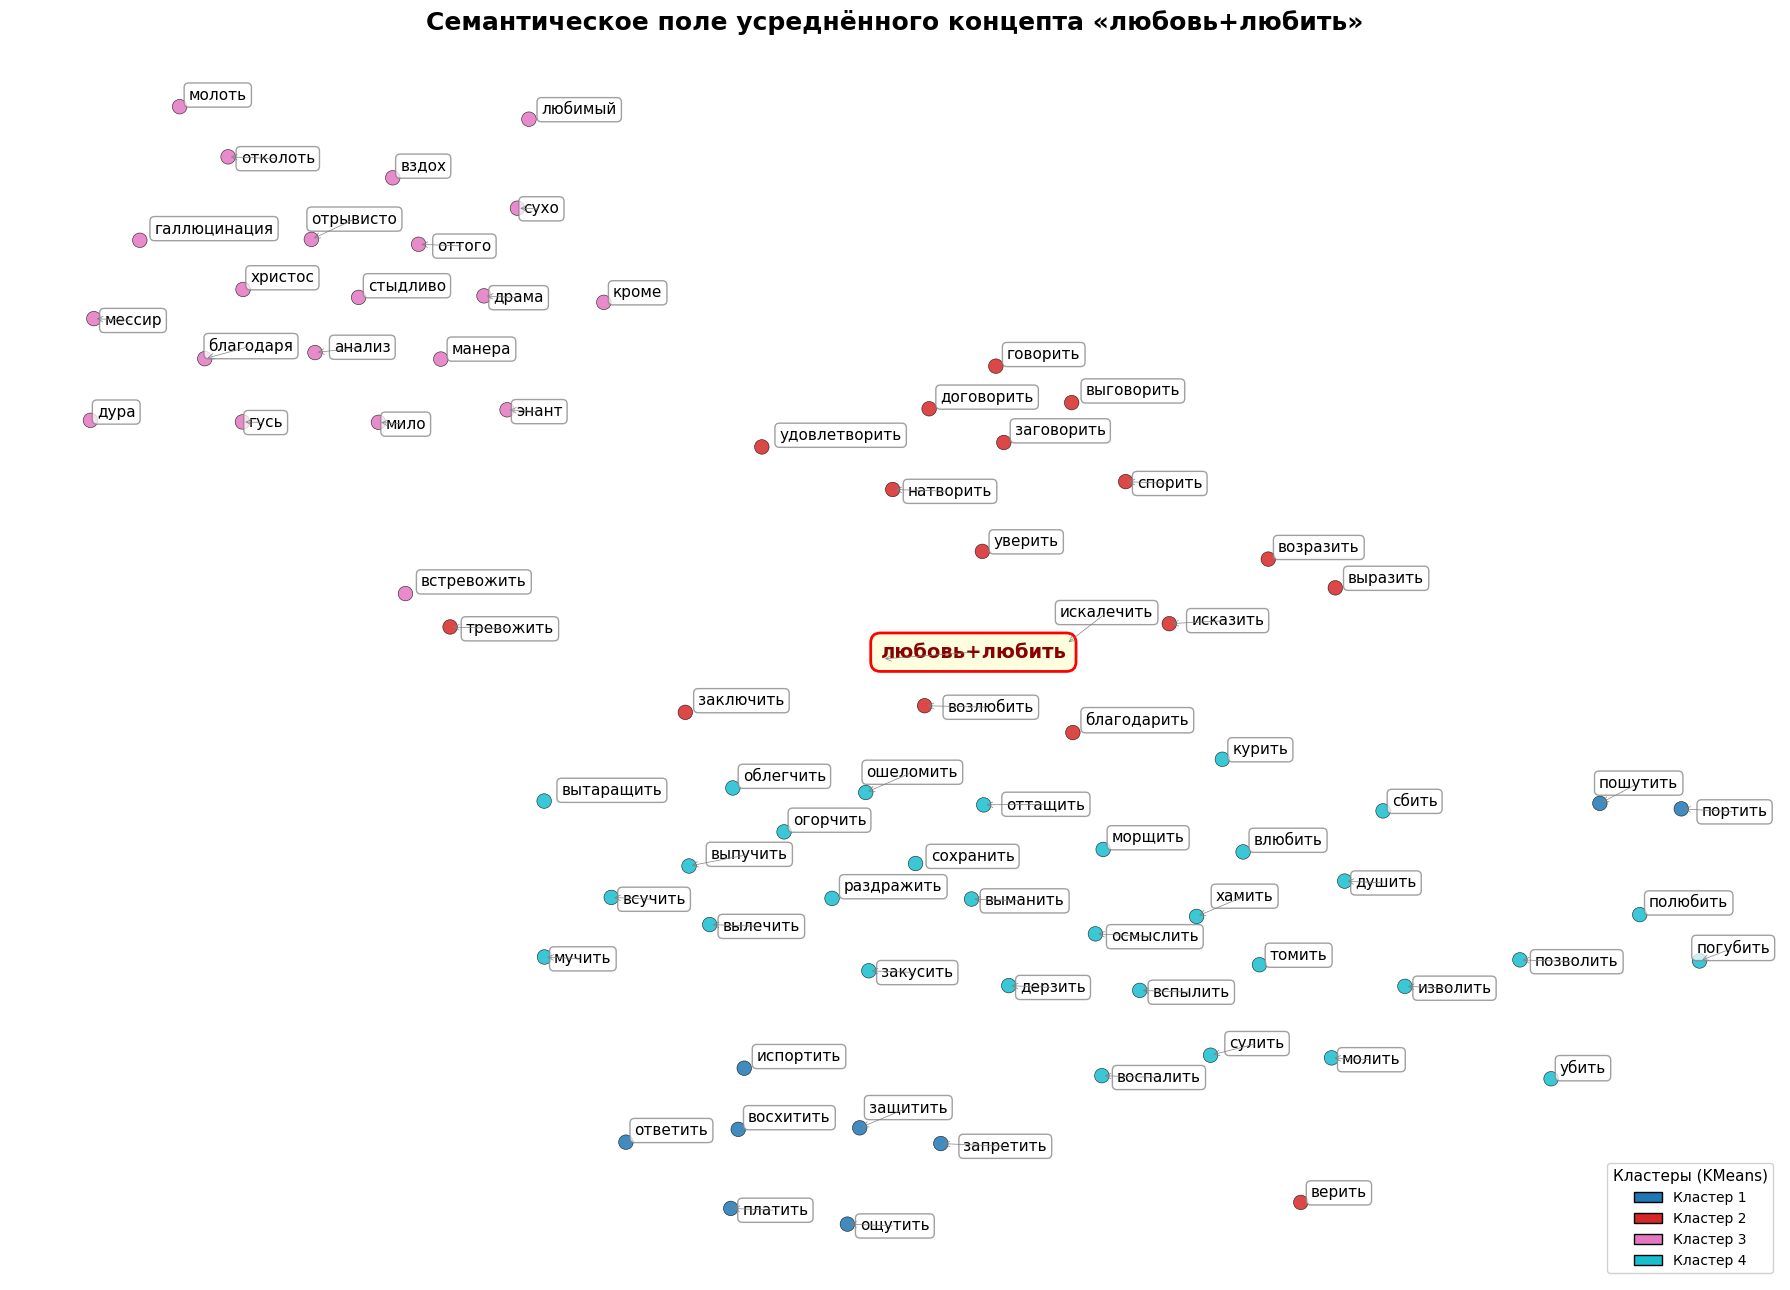

In [ ]:
def visualize_combined_field(model=None, words_to_combine=None, topn=80, n_clusters=4,
                              precomputed=None):
    if precomputed is not None:
        words, vectors, labels, vectors_2d, baseword_label = precomputed
    else:
        words, vectors, labels, vectors_2d, baseword_label = cluster_combined_vector(
            model, words_to_combine=words_to_combine, topn=topn, n_clusters=n_clusters
        )
    if words is None:
        return

    # Фиксированная палитра — одинаковая формула для точек и легенды
    cmap = plt.cm.tab10
    COLORS = [cmap(i / (n_clusters - 1)) for i in range(n_clusters)]
    point_colors = [COLORS[label] for label in labels]

    fig, ax = plt.subplots(figsize=(18, 13))
    ax.scatter(
        vectors_2d[:, 0], vectors_2d[:, 1],
        c=point_colors, alpha=0.85, s=110, edgecolors='black', linewidth=0.4, zorder=2
    )

    texts = []
    for i, word in enumerate(words):
        if word == baseword_label:
            t = ax.text(
                vectors_2d[i, 0], vectors_2d[i, 1], word,
                fontsize=14, fontweight='bold', color='darkred',
                bbox=dict(facecolor='lightyellow', alpha=1.0,
                          edgecolor='red', boxstyle='round,pad=0.5', linewidth=2)
            )
        else:
            t = ax.text(
                vectors_2d[i, 0], vectors_2d[i, 1], word,
                fontsize=11,
                bbox=dict(facecolor='white', alpha=0.75,
                          edgecolor='grey', boxstyle='round,pad=0.3')
            )
        texts.append(t)

    adjust_text(
        texts,
        arrowprops=dict(arrowstyle='->', color='gray', lw=0.5),
        force_points=(0.5, 0.5),
        force_text=(0.8, 0.8),
        expand_points=(1.5, 1.5),
        ax=ax
    )

    legend_elements = [
        mpatches.Patch(facecolor=COLORS[i], edgecolor='black', label=f'Кластер {i + 1}')
        for i in range(n_clusters)
    ]
    ax.legend(handles=legend_elements, title='Кластеры (KMeans)',
              loc='lower right', framealpha=0.9, fontsize=10, title_fontsize=11)

    plt.title(f"Семантическое поле усреднённого концепта «{baseword_label}»",
              fontsize=18, fontweight='bold', pad=15)
    ax.set_axis_off()
    plt.tight_layout()
    plt.show()


# Запуск
visualize_combined_field(fasttext_model, words_to_combine=('любовь', 'любить'), topn=80, n_clusters=4)